# 01. 사용자 행동 군집화
이용 패턴 기반으로 사용자를 그룹화합니다.

In [23]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.data_loader import load_processed, save_processed
from src.feature_engineering import add_user_features, build_trip_features
from src.evaluation import plot_cluster_profiles
print("\u2705 준비 완료")

✅ 준비 완료


## 1. 데이터 및 피처 준비

In [24]:
df = load_processed("rentals_clean")
df = add_user_features(df)
df = build_trip_features(df)

# 군집화에 사용할 수치 피처
df["hour"]       = df["rent_dt"].dt.hour
df["dow"]        = df["rent_dt"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# 가설: 출근형 / 퇴근형 / 그 외
# → "언제(hour) + 어떻게(use_min, use_m, speed_kmh)" 이용하는지만 사용
# → dow, gender_enc, age 제외: 가설과 무관한 인구통계 변수
CLUSTER_FEATS = ["use_min", "use_m", "speed_kmh", "hour"]

# is_weekend, dow는 시각화용으로만 유지
ALL_FEATS = CLUSTER_FEATS + ["dow", "is_weekend", "gender_enc"]
if "age" in df.columns:
    ALL_FEATS.append("age")

df_cl = df[ALL_FEATS].dropna()
print(f"군집화 데이터: {len(df_cl):,}행")
print(f"클러스터링 피처: {CLUSTER_FEATS}")

# 샘플링 (메모리 절약)
sample_n = min(100_000, len(df_cl))
df_sample = df_cl.sample(n=sample_n, random_state=42).reset_index(drop=True)

# 정규화 (CLUSTER_FEATS만)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[CLUSTER_FEATS])
print(f"\n정규화 완료: {X_scaled.shape}")

📂 Loaded rentals_clean.parquet → shape: (8559939, 27)
군집화 데이터: 6,600,060행
클러스터링 피처: ['use_min', 'use_m', 'speed_kmh', 'hour']

정규화 완료: (100000, 4)


## 2. 모델 선택 근거: K-Means vs GMM 비교

K-Means와 GMM을 k=2~6 범위에서
Silhouette, Calinski-Harabasz, Davies-Bouldin, Cluster Balance, Stability ARI
5개 지표로 비교해 최적 모델과 k를 결정합니다.

In [25]:
from src.clustering import evaluate_cluster_candidates, plot_model_comparison
import os

candidate_results = evaluate_cluster_candidates(
    df_sample,
    feature_cols=CLUSTER_FEATS,
    cluster_range=range(2, 7),
    random_states=(21, 42, 99),
)
print(candidate_results.to_string(index=False))

os.makedirs("../reports/tables", exist_ok=True)
candidate_results.to_csv("../reports/tables/cluster_model_comparison.csv", index=False)

fig_path = plot_model_comparison(candidate_results, save_name="cluster_model_comparison")
print(f"\n저장: {fig_path}")

# 가설 검증: 출근형 / 퇴근형 / 그 외
best_k = 3
print(f"\n✅ 선택된 k: {best_k}")

평가 중: model=kmeans, k=2
평가 중: model=gmm, k=2
평가 중: model=kmeans, k=3
평가 중: model=gmm, k=3
평가 중: model=kmeans, k=4
평가 중: model=gmm, k=4
평가 중: model=kmeans, k=5
평가 중: model=gmm, k=5
평가 중: model=kmeans, k=6
평가 중: model=gmm, k=6
 model  n_clusters  silhouette  calinski_harabasz  davies_bouldin  cluster_balance  stability_ari
kmeans           2    0.439992       36723.589078        1.274522          0.16013       0.999729
kmeans           4    0.343780       41639.508522        1.025172          0.05848       0.998200
kmeans           6    0.316998       38641.539336        0.999809          0.02156       0.994943
kmeans           3    0.314676       39158.283260        1.149816          0.13074       0.995434
   gmm           2    0.308334       29503.737168        1.594243          0.30112       0.999727
kmeans           5    0.301844       40324.098494        1.062823          0.05733       0.979080
   gmm           4    0.086459       19313.686159        2.291100          0.12968       

## 3. K-Means 클러스터링

In [26]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_sample["cluster"] = labels

print(f"클러스터별 데이터 수:")
print(df_sample["cluster"].value_counts().sort_index())

클러스터별 데이터 수:
cluster
0    51547
1    35279
2    13174
Name: count, dtype: int64


## 4. 클러스터 프로파일 분석

In [27]:
profile = df_sample.groupby("cluster")[CLUSTER_FEATS].mean().round(2)
print("클러스터별 평균 프로파일:")
print(profile.T)

클러스터별 평균 프로파일:
cluster          0        1        2
use_min      13.41     9.66    70.44
use_m      1496.09  1481.85  6247.48
speed_kmh     7.84     9.97     6.35
hour         17.45     7.82    14.43


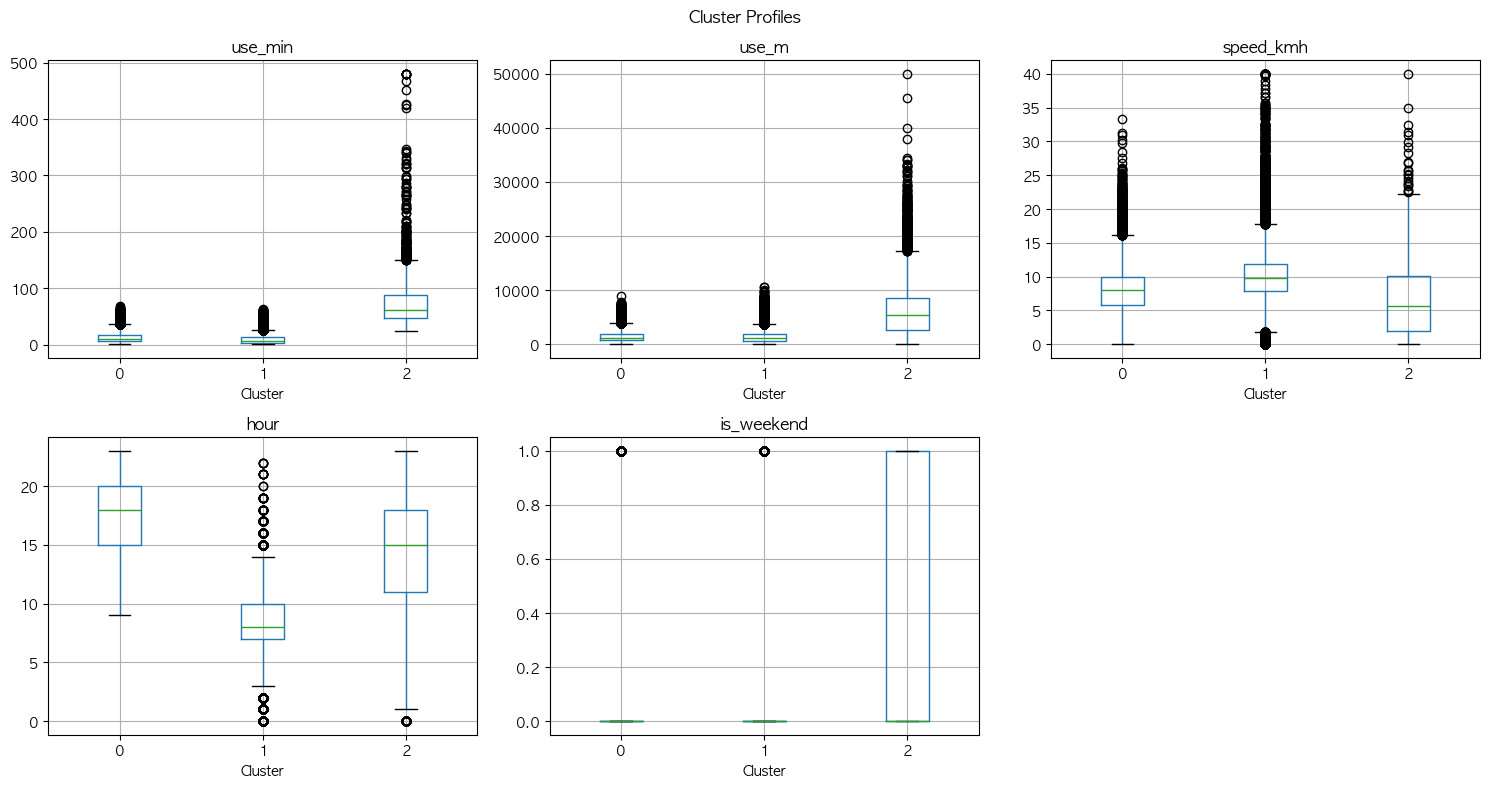

In [28]:
plot_cluster_profiles(
    df_sample,
    feature_cols=["use_min", "use_m", "speed_kmh", "hour", "is_weekend"],
    cluster_col="cluster",
    save_name="cluster_profiles"
)

## 5. PCA 기반 2D 시각화

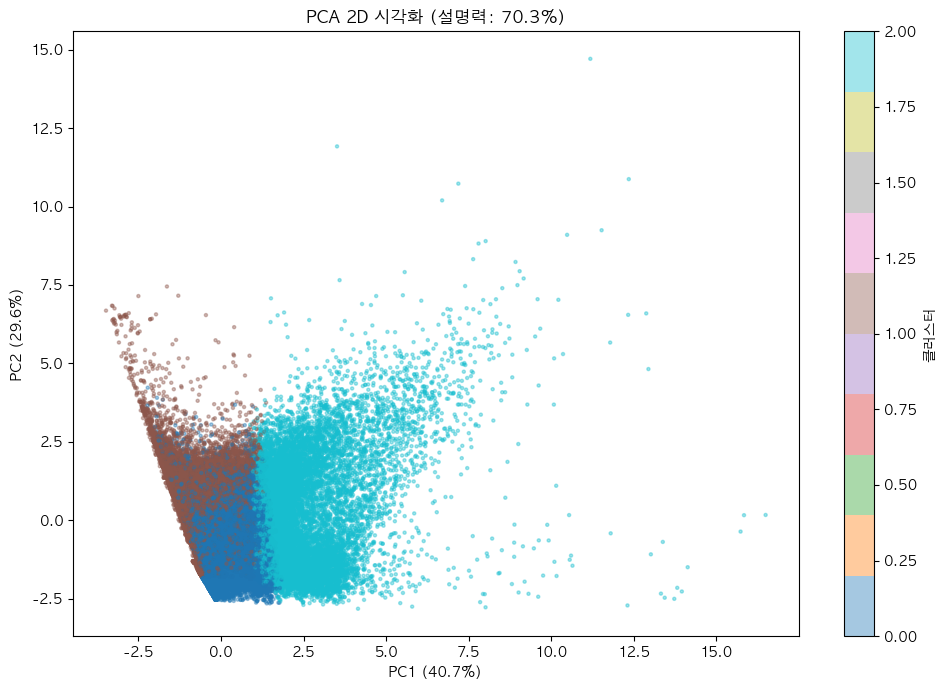

In [29]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=labels, cmap="tab10", alpha=0.4, s=5)
plt.colorbar(scatter, label="클러스터")
plt.title(f"PCA 2D 시각화 (설명력: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.savefig("../reports/figures/pca_clusters.png", dpi=150)
plt.show()

## 6. 클러스터 특성 기반 이름 부여

클러스터 이름 부여 완료:
cluster_name
짧은 저녁형     51547
짧은 오전형     35279
장거리·여가형    13174
Name: count, dtype: int64

클러스터별 hour 평균 (검증):
cluster
0    17.45
1     7.82
2    14.43
Name: hour, dtype: float64


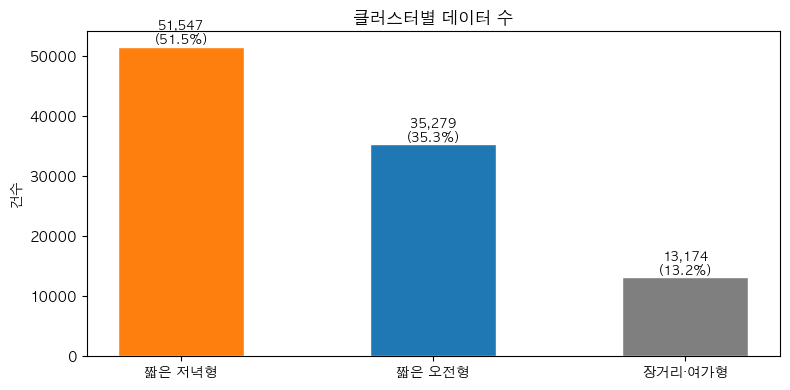

In [35]:
# 클러스터 이름 부여 (프로파일 기반)
# Cluster 0: hour 중앙값 ~18시, 짧은 이용 → 퇴근형
# Cluster 1: hour 중앙값 ~8시, 짧은 이용, 빠른 속도 → 출근형
# Cluster 2: use_min 길고(~60분), use_m 높고, is_weekend 포함 → 그 외(장거리·여가형)
cluster_names = {
    0: "짧은 저녁형",
    1: "짧은 오전형",
    2: "장거리·여가형",
}
color_map_base = {
    "짧은 저녁형": "#ff7f0e",
    "짧은 오전형": "#1f77b4",
    "장거리·여가형":  "#7f7f7f",
}

df_sample["cluster_name"] = df_sample["cluster"].map(cluster_names)

print("클러스터 이름 부여 완료:")
print(df_sample["cluster_name"].value_counts())
print("\n클러스터별 hour 평균 (검증):")
print(df_sample.groupby("cluster")["hour"].mean().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
counts = df_sample["cluster_name"].value_counts()
total = counts.sum()
ax.bar(counts.index, counts.values,
       color=[color_map_base[n] for n in counts.index],
       edgecolor="white", width=0.5)
ax.set_title("클러스터별 데이터 수")
ax.set_ylabel("건수")
for p in ax.patches:
    cnt = int(p.get_height())
    pct = cnt / total * 100
    ax.text(p.get_x() + p.get_width()/2, cnt + 100,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_names.png", dpi=150)
plt.show()

## 7. 저장

## 8. 추가 시각화 — 이용시간·이용거리 산포도 / 24시간·요일 분포 / 주말 비중

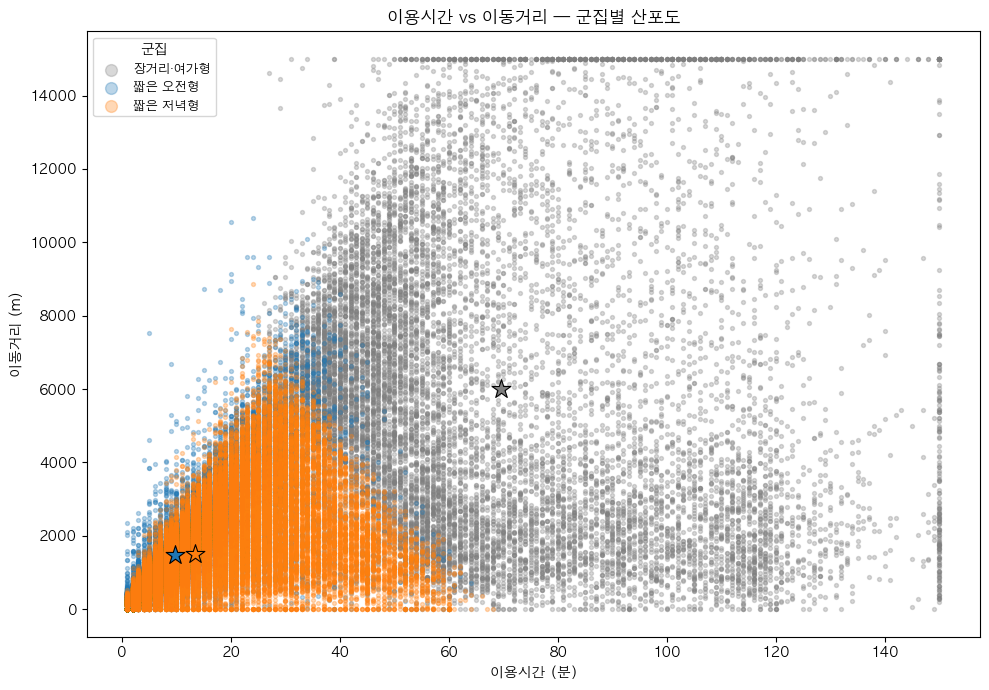

In [38]:
# 클러스터 이름 매핑
name_map = {
    0: "짧은 저녁형",
    1: "짧은 오전형",
    2: "장거리·여가형",
}
color_map = {
    "짧은 저녁형": "#ff7f0e",
    "짧은 오전형": "#1f77b4",
    "장거리·여가형":  "#7f7f7f",
}

df_sample["cluster_name"] = df_sample["cluster"].map(name_map)

# ── 1. 이용시간 - 이동거리 2D 산포도 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for name, grp in df_sample.groupby("cluster_name"):
    ax.scatter(
        grp["use_min"].clip(0, 150),
        grp["use_m"].clip(0, 15000),
        label=name, alpha=0.3, s=8, color=color_map[name]
    )

for cid, name in name_map.items():
    cx = df_sample[df_sample["cluster"] == cid]["use_min"].clip(0, 150).mean()
    cy = df_sample[df_sample["cluster"] == cid]["use_m"].clip(0, 15000).mean()
    ax.scatter(cx, cy, color=color_map[name], s=200, marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)

ax.set_xlabel("이용시간 (분)")
ax.set_ylabel("이동거리 (m)")
ax.set_title("이용시간 vs 이동거리 — 군집별 산포도")
ax.legend(title="군집", markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_scatter_2d.png", dpi=150)
plt.show()

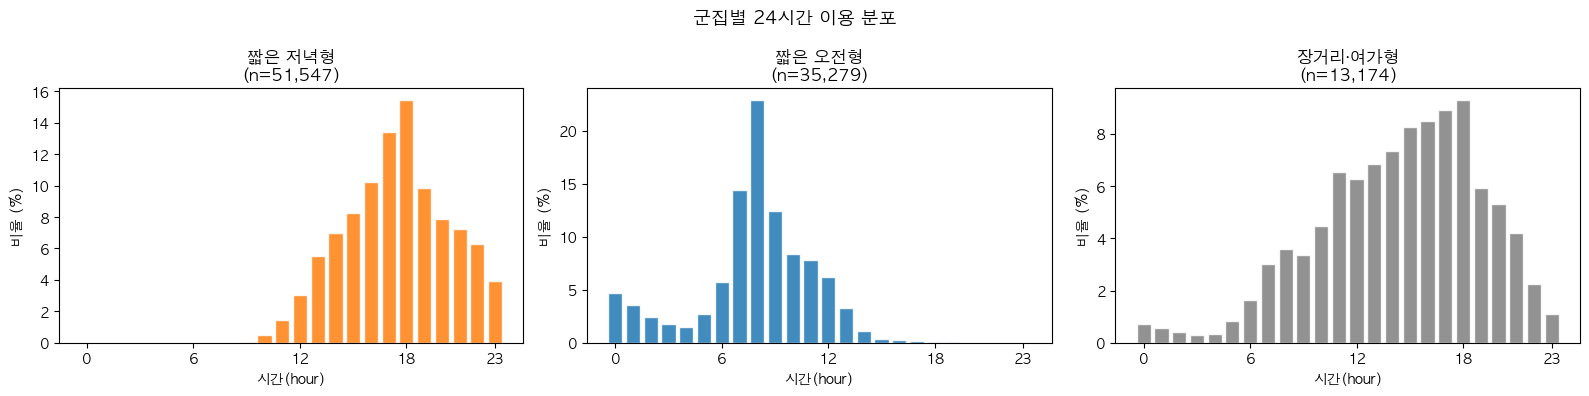

짧은 저녁형: 피크 18시, 상위 3시간대 [18, 17, 16]
짧은 오전형: 피크 8시, 상위 3시간대 [8, 7, 9]
장거리·여가형: 피크 18시, 상위 3시간대 [18, 17, 16]


In [39]:
# ── 2. 군집별 24시간 분포 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (cid, name) in zip(axes, name_map.items()):
    grp = df_sample[df_sample["cluster"] == cid]
    hr = grp["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
    hr_pct = hr / hr.sum() * 100
    ax.bar(hr_pct.index, hr_pct.values, color=color_map[name], alpha=0.85, edgecolor="white")
    ax.set_title(f"{name}\n(n={len(grp):,})")
    ax.set_xlabel("시간(hour)")
    ax.set_ylabel("비율 (%)")
    ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle("군집별 24시간 이용 분포", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_hour_dist.png", dpi=150)
plt.show()

for cid, name in name_map.items():
    grp = df_sample[df_sample["cluster"] == cid]
    peak = grp["hour"].value_counts().idxmax()
    top3 = grp["hour"].value_counts().head(3).index.tolist()
    print(f"{name}: 피크 {peak}시, 상위 3시간대 {top3}")

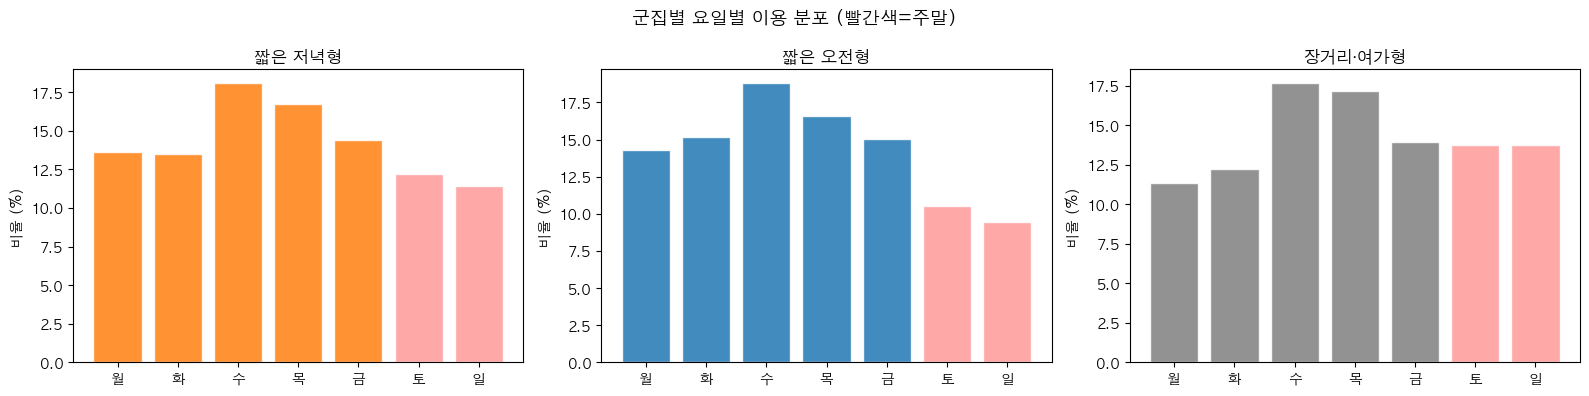

=== 주말 비중 실측 ===
짧은 저녁형: 주말 비중 23.6%  (전체 평균 22.9% 대비 1.03배)
짧은 오전형: 주말 비중 20.0%  (전체 평균 22.9% 대비 0.88배)
장거리·여가형: 주말 비중 27.6%  (전체 평균 22.9% 대비 1.21배)


In [40]:
# ── 3. 군집별 요일별 분포 + 주말 비중 실측 ────────────────────────────────────
dow_labels = ["월", "화", "수", "목", "금", "토", "일"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (cid, name) in zip(axes, name_map.items()):
    grp = df_sample[df_sample["cluster"] == cid]
    dw = grp["dow"].value_counts().sort_index().reindex(range(7), fill_value=0)
    dw_pct = dw / dw.sum() * 100
    bar_colors = ["#ff9999" if i >= 5 else color_map[name] for i in range(7)]
    ax.bar(range(7), dw_pct.values, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels)
    ax.set_title(f"{name}")
    ax.set_ylabel("비율 (%)")

plt.suptitle("군집별 요일별 이용 분포 (빨간색=주말)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_dow_dist.png", dpi=150)
plt.show()

print("=== 주말 비중 실측 ===")
total_weekend_pct = (df_sample["is_weekend"].sum() / len(df_sample)) * 100

for cid, name in name_map.items():
    grp = df_sample[df_sample["cluster"] == cid]
    weekend_pct = grp["is_weekend"].mean() * 100
    ratio = weekend_pct / total_weekend_pct
    print(f"{name}: 주말 비중 {weekend_pct:.1f}%  (전체 평균 {total_weekend_pct:.1f}% 대비 {ratio:.2f}배)")

In [41]:
# 클러스터 결과 저장
save_processed(df_sample, "user_clusters")

# 모델 저장
model_dir = Path("../models/clustering")
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(kmeans, model_dir / f"kmeans_k{best_k}.pkl")
joblib.dump(scaler, model_dir / "cluster_scaler.pkl")

print(f"\u2705 KMeans 모델 저장: models/clustering/kmeans_k{{best_k}}.pkl")
print(f"\u2705 클러스터 데이터 저장: data/processed/user_clusters.parquet")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/user_clusters.parquet  (1.8 MB)
✅ KMeans 모델 저장: models/clustering/kmeans_k{best_k}.pkl
✅ 클러스터 데이터 저장: data/processed/user_clusters.parquet
